In [1]:
# libraries
if (!require("dplyr")) install.packages("dplyr")
if (!require("car")) install.packages("car")
if (!require("lmtest")) install.packages("lmtest")
if (!require("sandwich")) install.packages("sandwich")
if (!require("ggplot2")) install.packages("ggplot2")
if (!require("stargazer")) install.packages("stargazer")
library(dplyr)
library(car)
library(lmtest)
library(sandwich)
library(ggplot2)
library(stargazer)

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: car

Loading required package: carData


Attaching package: ‘car’


The following object is masked from ‘package:dplyr’:

    recode


Loading required package: lmtest

Loading required package: zoo


Attaching package: ‘zoo’


The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric


Loading required package: sandwich

Warning message in library(package, lib.loc = lib.loc, character.only = TRUE, logical.return = TRUE, :
“there is no package called ‘sandwich’”
Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Loading required package: ggplot2

Loading required package: stargazer


Please cite as: 


 Hlavac, Marek (2022). stargazer: Well-Formatted Regression and Summary St

In [2]:
# Datasets assignment to variables
census_data <- read.csv("CensusLocalAreaProfiles2016.csv", header = FALSE)
cultural_spaces <- read.csv("fixed_Cultural spaces(in).csv") # "Fixed" as UTF-8 encoding problem arose while trying to open
public_art <- read.csv("fixed_Public art(in).csv") # Fixed through Rstudio by saving with encoding UTF-8

In [3]:
average_income <- as.numeric(census_data[1887, 3:24])  # Average Total income (t=2015), column 1887, rows 3-24, excluded 25-26 (Vancouver CSD & Vancouver CMA is 25 and 26)
population_density <- as.numeric(gsub(",", "", census_data[6, 3:24]))  # Population density (t=2015), column 6, rows 3-24, excluded 25-26, taking out "," for just number
neighborhoods <- trimws(tolower(as.character(census_data[5, 3:24])))  # Neighborhood names, column 5, rows 3-24, excluded 25-26, taking out white-space
census_df <- data.frame(
    Neighborhood = neighborhoods,
    AI = average_income,
    PD = population_density
)
head(census_df,22)

,Neighborhood,AI,PD
,<chr>,<dbl>,<dbl>
1,arbutus-ridge,62675,15295
2,downtown,63251,62030
3,dunbar-southlands,78117,21425
4,fairview,61627,33620
5,grandview-woodland,42896,29175
6,hastings-sunrise,38258,34575
7,kensington-cedar cottage,38411,49325
8,kerrisdale,77248,13975
9,killarney,39013,29325


In [4]:
# Cultural Spaces Data (t=2014-2020)
cultural_spaces <- cultural_spaces %>%
    mutate(
        Neighborhood = trimws(tolower(LOCAL_AREA)) # Common Variable for Neighborhood across 3 files
    ) %>%
    group_by(Neighborhood) %>%
    summarise(
        Private = sum(OWNERSHIP == "Privately Owned", na.rm = TRUE) # Collect all the privately owned, reject NA
)
head(cultural_spaces,25)

Neighborhood,Private
<chr>,<int>
,0
downtown,240
downtown eastside,10
dunbar-southlands,0
fairview,137
grandview-woodland,103
hastings-sunrise,5
kensington-cedar cottage,11
kerrisdale,0


In [5]:
# Add missing neighborhoods to cultural_spaces, 
missing_in_cultural <- setdiff(census_df$Neighborhood, cultural_spaces$Neighborhood)
cultural_spaces <- cultural_spaces %>%
    bind_rows(data.frame(
        Neighborhood = missing_in_cultural,
        Private = 0 # We don't have the data and it probably is 0 as if not, it would have been collected.
))

In [6]:
# Public Art Data
public_art <- public_art %>%
    mutate(
        Geo.Local.Area = trimws(tolower(Geo.Local.Area)), # delete whitespace, all lowercase
        Neighbourhood = trimws(tolower(Neighbourhood)), # do the same for existing neighborhoods in neighborhood variable
        Neighborhood = case_when(
            !is.na(Geo.Local.Area) & Geo.Local.Area != "" ~ Geo.Local.Area, # Geo.Local.Area not missing, not empty, use for neighborhood 
            !is.na(Neighbourhood) & Neighbourhood != "" ~ Neighbourhood, # Geo.Local.Area missing, Neighborhood has value, assign neighborhood to neighborhood variable
            TRUE ~ NA_character_ # If both Geo and Neighbor has missing, set Neighborhood to NA
        )
    ) %>%
filter(!is.na(Neighborhood) & Neighborhood != "") %>% # Remove missing neighborhood, empty or NA
group_by(Neighborhood) %>% # Grouped by neighborhood as the function suggests
summarise(Public_Art_Count = n(), .groups = "drop") # get number of rows in neighborhood, store in variable Public_Art_Count, remove grouping structure

In [7]:
# Add missing neighborhoods to public_art, same thing
missing_in_public_art <- setdiff(census_df$Neighborhood, public_art$Neighborhood)
public_art <- public_art %>%
    bind_rows(data.frame(
        Neighborhood = missing_in_public_art,
        Public_Art_Count = 0
    ))

In [8]:
# Merge All Data, final_data ready for regression.
final_data <- census_df %>%
    left_join(cultural_spaces, by = "Neighborhood") %>%
    left_join(public_art, by = "Neighborhood")

In [9]:
# Summary Statistics
stargazer(
    final_data[, c("Public_Art_Count", "Private", "AI", "PD")],
    type = "text",
    title = "Summary Statistics",
    summary.stat = c("mean", "median", "sd", "min", "max", "n")
)


Summary Statistics
Statistic           Mean     Median   St. Dev.   Min     Max   N 
-----------------------------------------------------------------
Public_Art_Count   26.773     11.5     52.305     0      249   22
Private            43.136      8       70.964     0      240   22
AI               54,739.500 50,156.5 21,142.880 31,534 118,668 22
PD               28,778.860  29,250  15,188.880 7,970  62,030  22
-----------------------------------------------------------------


In [10]:
# Inspect Final Data
glimpse(final_data)
head(final_data,22)

Rows: 22
Columns: 5
$ Neighborhood     <chr> "arbutus-ridge", "downtown", "dunbar-southlands", "fa…
$ AI               <dbl> 62675, 63251, 78117, 61627, 42896, 38258, 38411, 7724…
$ PD               <dbl> 15295, 62030, 21425, 33620, 29175, 34575, 49325, 1397…
$ Private          <dbl> 0, 240, 0, 137, 103, 5, 11, 0, 0, 23, 28, 161, 15, 14…
$ Public_Art_Count <dbl> 0, 249, 2, 21, 18, 7, 24, 1, 5, 23, 17, 62, 4, 7, 14,…


,Neighborhood,AI,PD,Private,Public_Art_Count
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
1,arbutus-ridge,62675,15295,0,0
2,downtown,63251,62030,240,249
3,dunbar-southlands,78117,21425,0,2
4,fairview,61627,33620,137,21
5,grandview-woodland,42896,29175,103,18
6,hastings-sunrise,38258,34575,5,7
7,kensington-cedar cottage,38411,49325,11,24
8,kerrisdale,77248,13975,0,1
9,killarney,39013,29325,0,5


In [11]:
# Fit Simple Regression Model for starting direction
simple_model <- lm(Public_Art_Count ~ Private, data = final_data)

In [12]:
# Model Summary
cat("\nBasic Simple Regression Model Summary:\n")
summary(simple_model) #Surprisingly very good


Basic Simple Regression Model Summary:



Call:
lm(formula = Public_Art_Count ~ Private, data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-58.975  -3.058  -0.758   3.801 110.645 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   2.3230     8.6029    0.27     0.79    
Private       0.5668     0.1054    5.38 2.89e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 34.26 on 20 degrees of freedom
Multiple R-squared:  0.5914,	Adjusted R-squared:  0.5709 
F-statistic: 28.94 on 1 and 20 DF,  p-value: 2.888e-05


In [13]:
# Breusch-Pagan Test
bp_test <- bptest(simple_model)
cat("\nBreusch-Pagan Test Results (Simple Model):\n")
print(bp_test) # BP test statistics large, p-value extremely small, reject null => Heteroskedastic


Breusch-Pagan Test Results (Simple Model):

	studentized Breusch-Pagan test

data:  simple_model
BP = 14.598, df = 1, p-value = 0.000133



In [14]:
# White's Test, even though we failed BP, just for fun
white_test <- bptest(simple_model, ~ fitted(simple_model) + I(fitted(simple_model)^2))
cat("\nWhite Test Results (Simple Model):\n")
print(white_test) # White test statistics large, p-value extremely small, reject null => Heteroskedastic


White Test Results (Simple Model):

	studentized Breusch-Pagan test

data:  simple_model
BP = 19.449, df = 2, p-value = 5.98e-05



In [15]:
# Robust Standard Errors, to get coefficient considering heteroskedasticity
cat("\nRobust Standard Errors (Simple Model):\n")
robust_se_simple <- coeftest(simple_model, vcov = vcovHC(simple_model, type = "HC1"))
print(robust_se_simple)


Robust Standard Errors (Simple Model):

t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   2.3230     5.1549  0.4506  0.65709  
Private       0.5668     0.2385  2.3765  0.02758 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



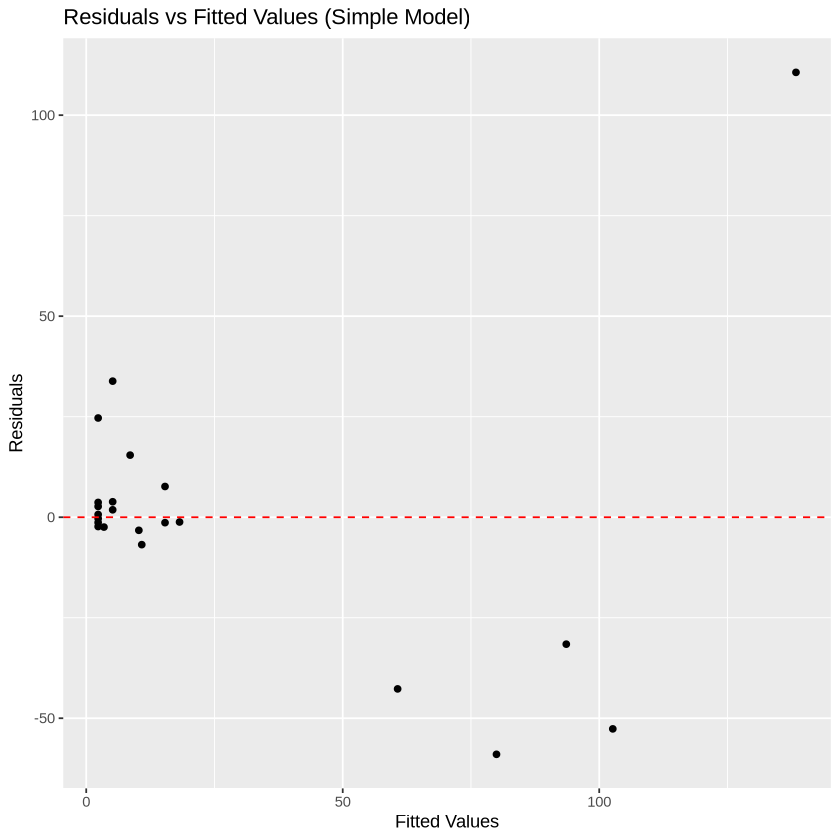

In [16]:
# Residual Check for Heteroskedasticity (Eyeball Check)
ggplot(final_data, aes(x = predict(simple_model), y = residuals(simple_model))) +
    geom_point() +
    geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
    labs(title = "Residuals vs Fitted Values (Simple Model)", x = "Fitted Values", y = "Residuals")

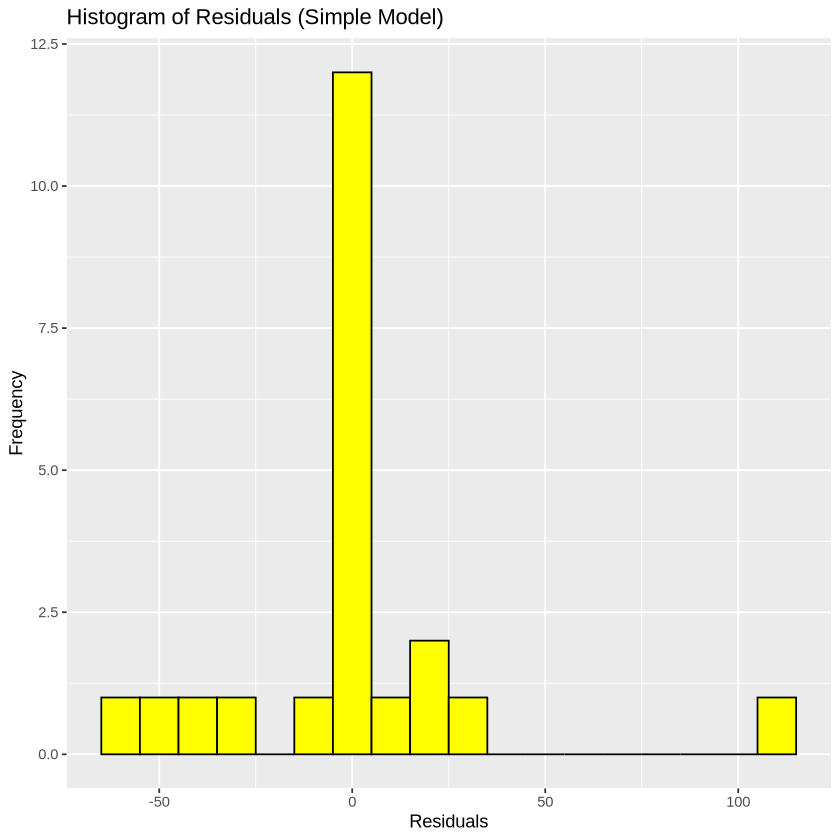

In [17]:
# Residual Histogram, should look ~ N
ggplot(final_data, aes(x = residuals(simple_model))) +
    geom_histogram(binwidth = 10, fill = "Yellow", color = "black") +
    labs(title = "Histogram of Residuals (Simple Model)", x = "Residuals", y = "Frequency")

In [18]:
# Revised Model with Controls
revised_model <- lm(Public_Art_Count ~ Private + AI + PD, data = final_data)

In [19]:
# Model Summary
cat("\nRevised Regression Model Summary:\n")
summary(revised_model)


Revised Regression Model Summary:



Call:
lm(formula = Public_Art_Count ~ Private + AI + PD, data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-65.011  -9.647   2.340   8.811  67.123 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -8.301e+01  2.559e+01  -3.244  0.00451 ** 
Private      4.924e-01  8.824e-02   5.580  2.7e-05 ***
AI           8.061e-04  3.106e-04   2.595  0.01829 *  
PD           1.543e-03  4.513e-04   3.420  0.00305 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 27.33 on 18 degrees of freedom
Multiple R-squared:  0.766,	Adjusted R-squared:  0.727 
F-statistic: 19.64 on 3 and 18 DF,  p-value: 6.591e-06


In [20]:
# VIF Value, very good VIF
vif_values <- vif(revised_model)
cat("\nVariance Inflation Factors (Revised Model):\n")
print(vif_values)


Variance Inflation Factors (Revised Model):
 Private       AI       PD 
1.102457 1.212809 1.320739 


In [21]:
# Breush-Pagan Test, still pretty bad
bp_test_revised <- bptest(revised_model)
cat("\nBreusch-Pagan Test Results (Revised Model):\n")
print(bp_test_revised)


Breusch-Pagan Test Results (Revised Model):

	studentized Breusch-Pagan test

data:  revised_model
BP = 14.293, df = 3, p-value = 0.002532



In [22]:
# White's Test, even worse
white_test_revised <- bptest(revised_model, ~ fitted(revised_model) + I(fitted(revised_model)^2))
cat("\nWhite Test Results (Revised Model):\n")
print(white_test_revised)


White Test Results (Revised Model):

	studentized Breusch-Pagan test

data:  revised_model
BP = 15.406, df = 2, p-value = 0.0004516



In [23]:
# Robust Standard Errors
cat("\nRobust Standard Errors (Revised Model):\n")
robust_se_revised <- coeftest(revised_model, vcov = vcovHC(revised_model, type = "HC1"))
print(robust_se_revised)


Robust Standard Errors (Revised Model):

t test of coefficients:

               Estimate  Std. Error t value Pr(>|t|)   
(Intercept) -8.3006e+01  3.2960e+01 -2.5184 0.021470 * 
Private      4.9236e-01  1.3972e-01  3.5239 0.002425 **
AI           8.0614e-04  2.9568e-04  2.7264 0.013852 * 
PD           1.5432e-03  5.6078e-04  2.7519 0.013118 * 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



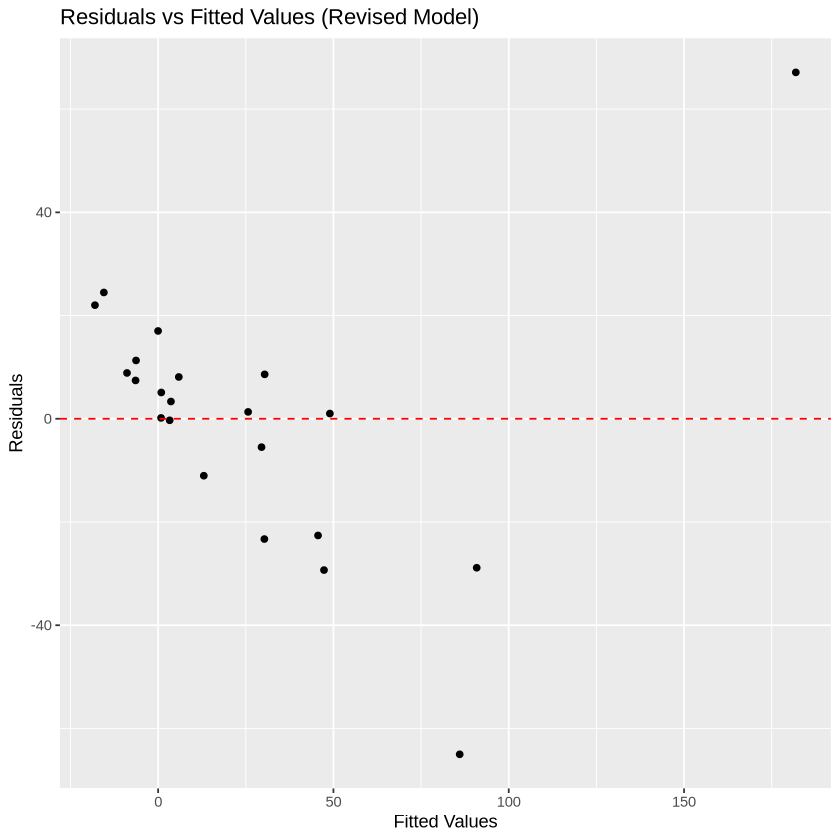

In [24]:
# Residual Heteroskedastisticity, clearly so
ggplot(final_data, aes(x = predict(revised_model), y = residuals(revised_model))) +
    geom_point() +
    geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
    labs(title = "Residuals vs Fitted Values (Revised Model)", x = "Fitted Values", y = "Residuals")

In [25]:
# Compare Adjusted R-squared
cat("\nComparison of Adjusted R-squared:\n")
cat("Simple Model Adjusted R-squared:", summary(simple_model)$adj.r.squared, "\n")
cat("Revised Model Adjusted R-squared:", summary(revised_model)$adj.r.squared, "\n")

# Compare Residual Standard Errors
cat("\nComparison of Residual Standard Errors:\n")
cat("Simple Model Residual Standard Error:", summary(simple_model)$sigma, "\n")
cat("Revised Model Residual Standard Error:", summary(revised_model)$sigma, "\n") # Not needed btw, asked during OH


Comparison of Adjusted R-squared:
Simple Model Adjusted R-squared: 0.5709316 
Revised Model Adjusted R-squared: 0.7269731 

Comparison of Residual Standard Errors:
Simple Model Residual Standard Error: 34.26144 
Revised Model Residual Standard Error: 27.33035 


`geom_smooth()` using formula = 'y ~ x'


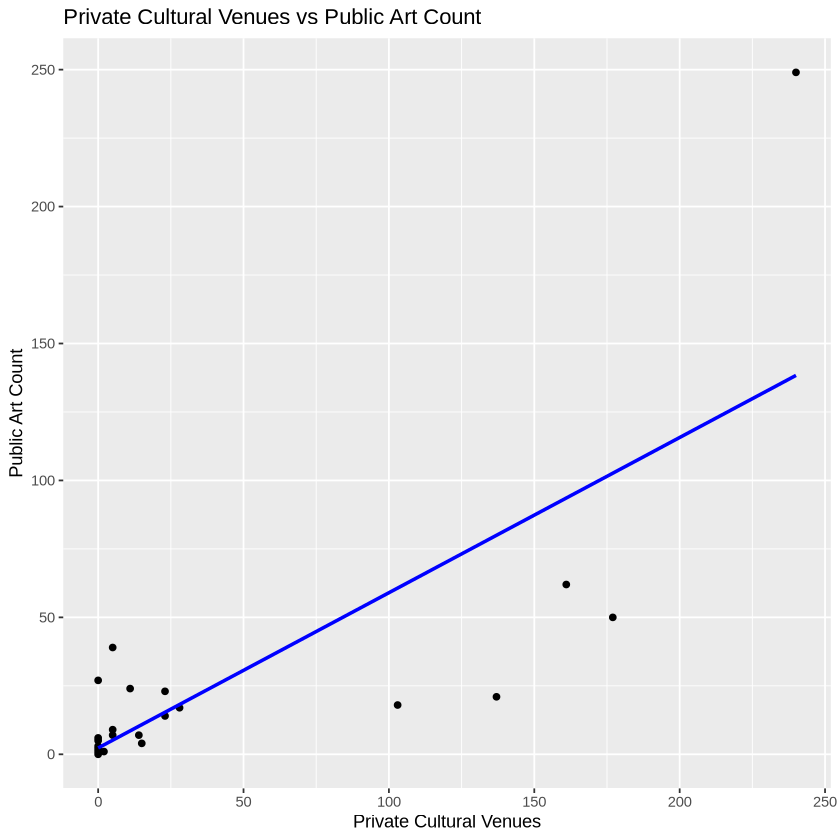

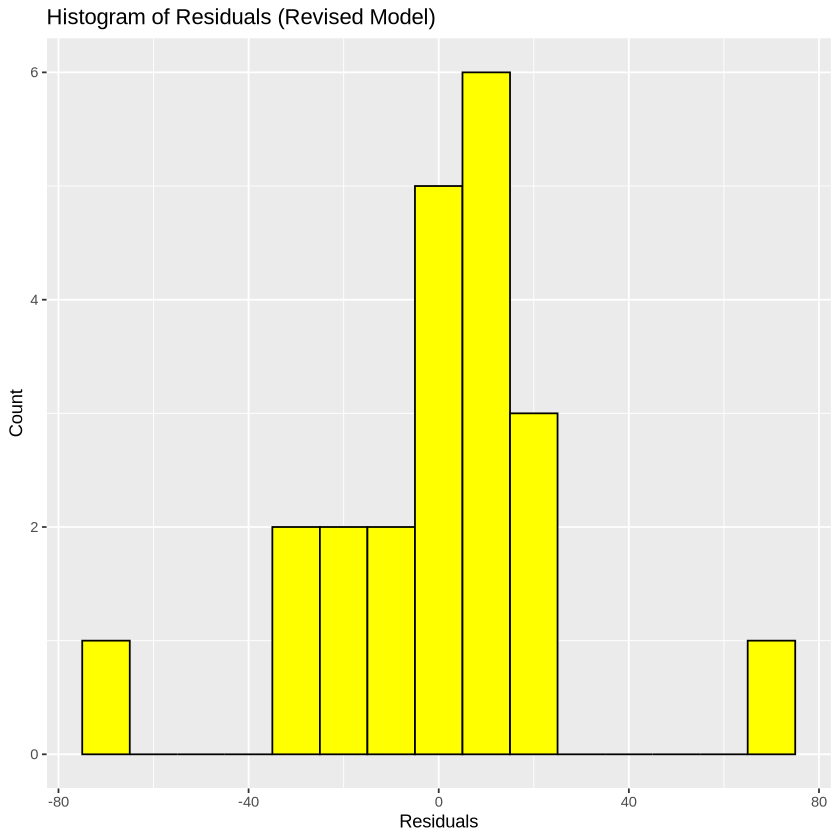

In [26]:
# Private vs Public Art Count => Private go up, Public art go up
ggplot(final_data, aes(x = Private, y = Public_Art_Count)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE, color = "blue") +
    labs(title = "Private Cultural Venues vs Public Art Count", x = "Private Cultural Venues", y = "Public Art Count")

# Residual Histogram for Revised Model
ggplot(final_data, aes(x = residuals(revised_model))) +
    geom_histogram(binwidth = 10, fill = "Yellow", color = "black") +
    labs(title = "Histogram of Residuals (Revised Model)", x = "Residuals", y = "Count")

In [27]:
# Robustness check for non-linear, quadratic controls
non_linear_model <- lm(Public_Art_Count ~ Private + AI + PD + I(AI^2) + I(PD^2), data = final_data)
summary(non_linear_model)


Call:
lm(formula = Public_Art_Count ~ Private + AI + PD + I(AI^2) + 
    I(PD^2), data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-43.634  -9.528   0.950  13.272  33.440 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  1.111e+01  4.155e+01   0.267  0.79259    
Private      4.095e-01  7.099e-02   5.769 2.88e-05 ***
AI           6.924e-04  1.014e-03   0.683  0.50464    
PD          -4.239e-03  1.521e-03  -2.788  0.01316 *  
I(AI^2)     -2.809e-09  7.359e-09  -0.382  0.70770    
I(PD^2)      8.747e-08  2.240e-08   3.904  0.00126 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 20.74 on 16 degrees of freedom
Multiple R-squared:  0.8802,	Adjusted R-squared:  0.8427 
F-statistic:  23.5 on 5 and 16 DF,  p-value: 7.599e-07


In [28]:
# Robustness check for interaction -> Higher Pop effects on => private effect on Y_i
interaction_model <- lm(Public_Art_Count ~ Private * PD + AI, data = final_data)
summary(interaction_model)


Call:
lm(formula = Public_Art_Count ~ Private * PD + AI, data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-45.439  -5.579  -0.587   4.436  35.010 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -6.430e-01  2.452e+01  -0.026  0.97938    
Private     -1.497e-01  1.481e-01  -1.011  0.32618    
PD           9.916e-05  4.311e-04   0.230  0.82082    
AI           7.618e-05  2.603e-04   0.293  0.77335    
Private:PD   1.727e-05  3.646e-06   4.738  0.00019 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 18.46 on 17 degrees of freedom
Multiple R-squared:  0.8991,	Adjusted R-squared:  0.8754 
F-statistic: 37.89 on 4 and 17 DF,  p-value: 2.939e-08


In [29]:
# Sub-sample Analysis (Heterogeneity)
high_income <- subset(final_data, AI > median(AI))
low_income <- subset(final_data, AI <= median(AI))

model_high_income <- lm(Public_Art_Count ~ Private + AI + PD, data = high_income)
model_low_income <- lm(Public_Art_Count ~ Private + AI + PD, data = low_income)
summary(model_high_income)
summary(model_low_income)


Call:
lm(formula = Public_Art_Count ~ Private + AI + PD, data = high_income)

Residuals:
    Min      1Q  Median      3Q     Max 
-64.660 -17.975   3.199  16.649  54.688 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -1.162e+02  6.740e+01  -1.725   0.1282  
Private      4.970e-01  2.558e-01   1.943   0.0931 .
AI           1.102e-03  7.519e-04   1.466   0.1860  
PD           1.960e-03  1.345e-03   1.457   0.1884  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 38.66 on 7 degrees of freedom
Multiple R-squared:  0.8006,	Adjusted R-squared:  0.7152 
F-statistic: 9.371 on 3 and 7 DF,  p-value: 0.007569



Call:
lm(formula = Public_Art_Count ~ Private + AI + PD, data = low_income)

Residuals:
     Min       1Q   Median       3Q      Max 
-19.5299  -2.9516  -0.7013   5.5978  15.1271 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)   
(Intercept) -4.410e+01  3.328e+01  -1.325    0.227   
Private      2.769e-01  7.912e-02   3.500    0.010 **
AI           8.731e-04  7.260e-04   1.203    0.268   
PD           5.367e-04  3.260e-04   1.646    0.144   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.37 on 7 degrees of freedom
Multiple R-squared:  0.6387,	Adjusted R-squared:  0.4839 
F-statistic: 4.125 on 3 and 7 DF,  p-value: 0.05591


In [30]:
# Iterate Estimation Model, Leaving out single neighborhood at a time
# It is to check if one neighborhood significantly influence the model
library(boot)
loo_results <- glm(Public_Art_Count ~ Private + AI + PD, data = final_data)
loo <- boot(data = final_data, statistic = function(data, i) {
    glm(Public_Art_Count ~ Private + AI + PD, data = data[i, ])$coefficients
}, R = nrow(final_data))
print(loo)


Attaching package: ‘boot’


The following object is masked from ‘package:car’:

    logit





ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = final_data, statistic = function(data, i) {
    glm(Public_Art_Count ~ Private + AI + PD, data = data[i, 
        ])$coefficients
}, R = nrow(final_data))


Bootstrap Statistics :
         original        bias     std. error
t1* -8.300631e+01 26.9756769706 4.620554e+01
t2*  4.923648e-01 -0.0884260829 1.672204e-01
t3*  8.061355e-04 -0.0002295118 4.748176e-04
t4*  1.543242e-03 -0.0004121262 7.974723e-04


In [31]:
# Bootstrap Standard Errors - Robust estimates
if (!require("boot")) install.packages("boot")
library(boot)
boot_model <- function(data, indices) {
    df <- data[indices, ]
    coef(lm(Public_Art_Count ~ Private + AI + PD, data = df))
}
boot_results <- boot(data = final_data, statistic = boot_model, R = 1000)
print(boot_results)


ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = final_data, statistic = boot_model, R = 1000)


Bootstrap Statistics :
         original        bias     std. error
t1* -8.300631e+01 15.9749119289 4.158686e+01
t2*  4.923648e-01 -0.0686391696 1.764681e-01
t3*  8.061355e-04 -0.0001418525 3.855662e-04
t4*  1.543242e-03 -0.0002478541 6.996613e-04


In [32]:
library(lmtest) # Check if DW is around 2, this is checking for autocorrelation
dwtest(revised_model)


	Durbin-Watson test

data:  revised_model
DW = 1.9842, p-value = 0.4967
alternative hypothesis: true autocorrelation is greater than 0


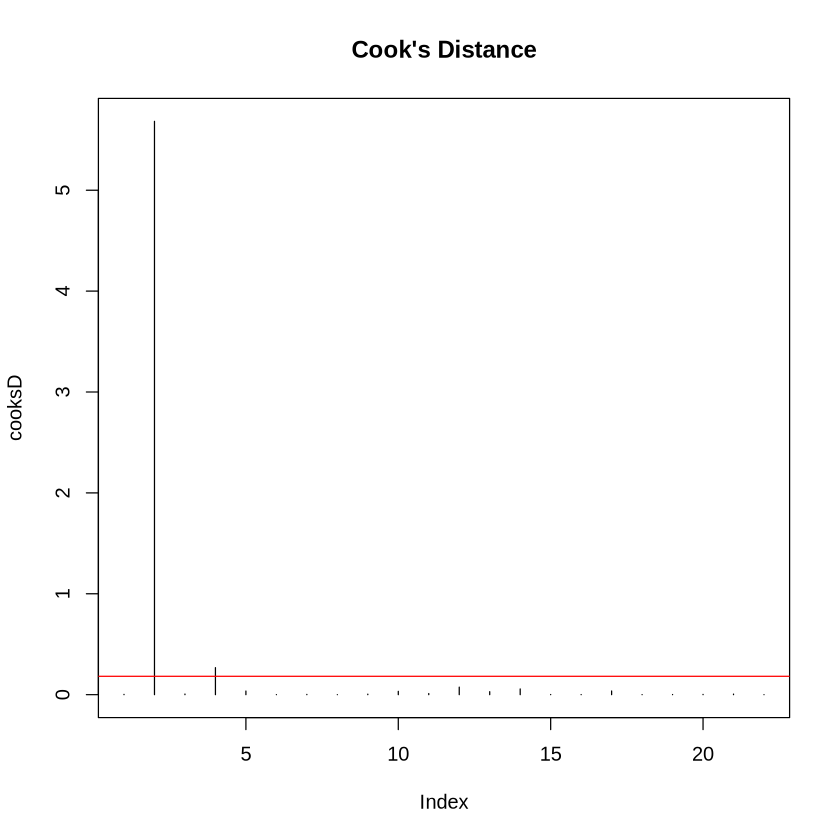

In [33]:
# How would Y_i change depending on taking out given neighborhood?
cooksD <- cooks.distance(revised_model)
plot(cooksD, type = "h", main = "Cook's Distance")
abline(h = 4 / nrow(final_data), col = "red")

In [34]:
# Neighborhood 2 and 5 significantly influence the outcome of the revised_model
final_data[c(2, 4), ]

,Neighborhood,AI,PD,Private,Public_Art_Count
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,downtown,63251,62030,240,249
4,fairview,61627,33620,137,21


In [35]:
# Regression Model excluding these two neighborhoods, compare Private estimates
model_exclude_DG<- lm(Public_Art_Count ~ Private + AI + PD, data = final_data[-c(2, 4), ])
summary(model_exclude_DG)


Call:
lm(formula = Public_Art_Count ~ Private + AI + PD, data = final_data[-c(2, 
    4), ])

Residuals:
     Min       1Q   Median       3Q      Max 
-17.5664  -4.3584   0.3365   5.6949  20.7208 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -2.566e+01  1.108e+01  -2.316  0.03413 *  
Private      2.955e-01  4.261e-02   6.935 3.36e-06 ***
AI           3.319e-04  1.226e-04   2.707  0.01555 *  
PD           5.674e-04  1.886e-04   3.009  0.00833 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 9.263 on 16 degrees of freedom
Multiple R-squared:  0.7588,	Adjusted R-squared:  0.7136 
F-statistic: 16.78 on 3 and 16 DF,  p-value: 3.391e-05


In [36]:
# Robustness check revealed better model. 
# Private-PD Model
private_pd_model <- lm(Public_Art_Count ~ Private * PD + I(PD^2), data = final_data)

In [37]:
# Model Summary
cat("\nModel Summary:\n")
summary(private_pd_model) # 93.93% -> Again, not important


Model Summary:



Call:
lm(formula = Public_Art_Count ~ Private * PD + I(PD^2), data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-30.937  -6.449   3.208   8.925  20.247 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.111e+01  1.300e+01   3.164 0.005675 ** 
Private     -2.150e-02  1.069e-01  -0.201 0.842958    
PD          -3.185e-03  9.815e-04  -3.245 0.004761 ** 
I(PD^2)      5.618e-08  1.663e-08   3.378 0.003577 ** 
Private:PD   1.245e-05  2.793e-06   4.459 0.000345 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.32 on 17 degrees of freedom
Multiple R-squared:  0.9393,	Adjusted R-squared:  0.9251 
F-statistic: 65.81 on 4 and 17 DF,  p-value: 4.057e-10


In [38]:
# Checking for VIF in the predictors used in the Private-PD model
cat("\nVIF Values:\n")
vif(private_pd_model, type = "predictor")


VIF Values:


GVIFs computed for predictors



,GVIF,Df,GVIF^(1/(2*Df)),Interacts With,Other Predictors
,<dbl>,<dbl>,<dbl>,<chr>,<chr>
Private,1,4,1,PD,--
PD,1,4,1,"I(PD^2), Private",--


In [39]:
# Breusch-Pagan Test, still bad, not as bad though
cat("\nBreusch-Pagan Test:\n")
bptest(private_pd_model)


Breusch-Pagan Test:



	studentized Breusch-Pagan test

data:  private_pd_model
BP = 4.8222, df = 4, p-value = 0.306


In [40]:
# White's Test for fun
cat("\nWhite Test:\n")
white_test <- bptest(private_pd_model, ~ fitted(private_pd_model) + I(fitted(private_pd_model)^2))
print(white_test)


White Test:

	studentized Breusch-Pagan test

data:  private_pd_model
BP = 6.4443, df = 2, p-value = 0.03987



In [41]:
# We need RSE for the coefficients validity assuming heteroskedasticity.
cat("\nRobust Standard Errors:\n")
robust_se <- coeftest(private_pd_model, vcov = vcovHC(private_pd_model, type = "HC"))
print(robust_se)


Robust Standard Errors:

t test of coefficients:

               Estimate  Std. Error t value  Pr(>|t|)    
(Intercept)  4.1112e+01  1.1305e+01  3.6368 0.0020394 ** 
Private     -2.1500e-02  1.1356e-01 -0.1893 0.8520842    
PD          -3.1852e-03  9.9966e-04 -3.1863 0.0054048 ** 
I(PD^2)      5.6176e-08  1.9016e-08  2.9542 0.0088804 ** 
Private:PD   1.2454e-05  3.1188e-06  3.9931 0.0009413 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1



In [42]:
# Checking for NA or Inf values for graph because it was keep messing up
summary(final_data)
colSums(is.na(final_data)) # Probably due to min. private = 0

 Neighborhood             AI               PD           Private      
 Length:22          Min.   : 31534   Min.   : 7970   Min.   :  0.00  
 Class :character   1st Qu.: 38562   1st Qu.:14305   1st Qu.:  0.00  
 Mode  :character   Median : 50156   Median :29250   Median :  8.00  
                    Mean   : 54740   Mean   :28779   Mean   : 43.14  
                    3rd Qu.: 63211   3rd Qu.:36019   3rd Qu.: 26.75  
                    Max.   :118668   Max.   :62030   Max.   :240.00  
 Public_Art_Count
 Min.   :  0.00  
 1st Qu.:  4.25  
 Median : 11.50  
 Mean   : 26.77  
 3rd Qu.: 23.75  
 Max.   :249.00  

Neighborhood               AI               PD          Private 
               0                0                0                0 
Public_Art_Count 
               0

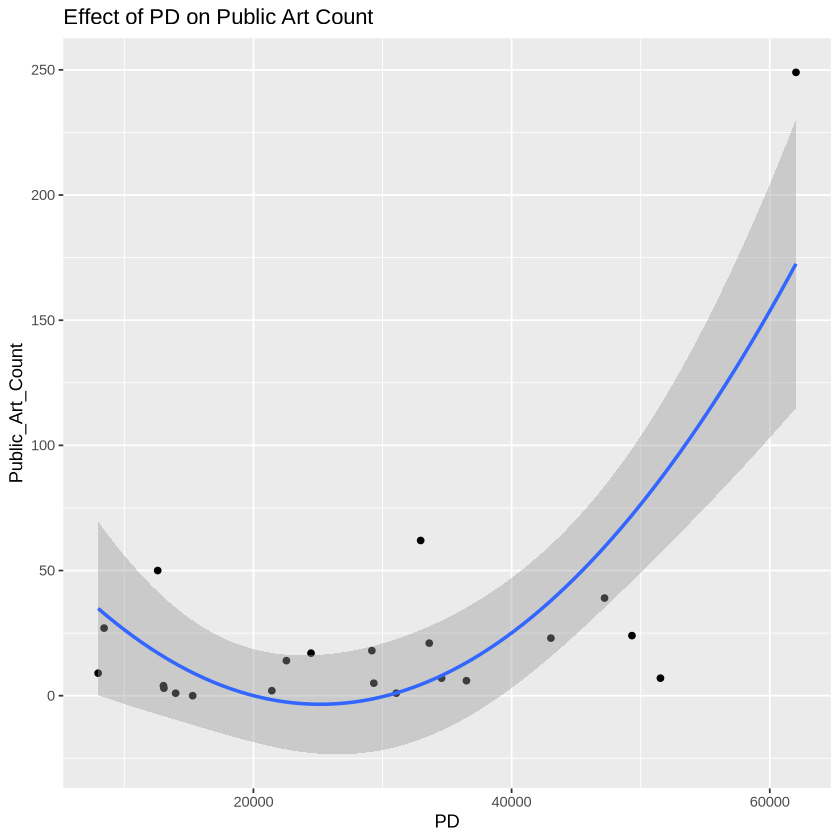

In [43]:
# Graph of Population density on Public art count
ggplot(final_data, aes(x = PD, y = Public_Art_Count)) +
    geom_point() +
    geom_smooth(method = "lm", formula = y ~ x + I(x^2)) +
    labs(title = "Effect of PD on Public Art Count")


Residual Heteroskedasticity Graph:


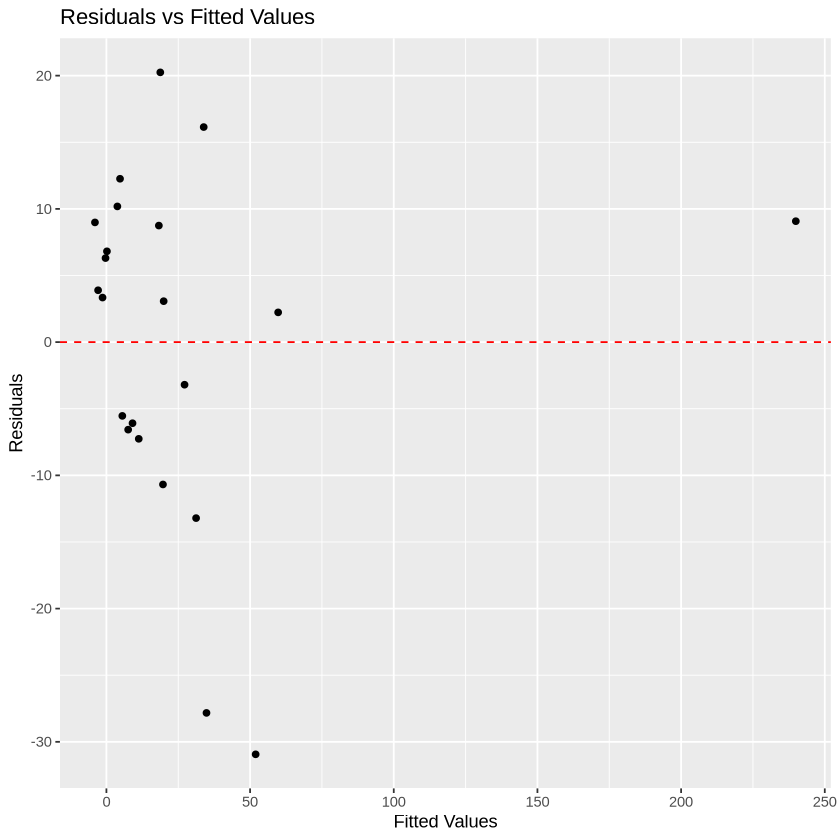

In [44]:
# Thomas Eyeball test for heteroskedasticity
cat("\nResidual Heteroskedasticity Graph:\n")
residuals <- resid(private_pd_model)
fitted_values <- fitted(private_pd_model)
ggplot(data.frame(residuals, fitted_values), aes(x = fitted_values, y = residuals)) +
    geom_point() +
    geom_hline(yintercept = 0, color = "red", linetype = "dashed") +
    ggtitle("Residuals vs Fitted Values") +
    xlab("Fitted Values") +
    ylab("Residuals")

In [45]:
# Comparison between three models
simple_model <- lm(Public_Art_Count ~ Private, data = final_data)
revised_model <- lm(Public_Art_Count ~ Private + AI + PD, data = final_data)
cat("\nComparison of Adjusted R-squared:\n")
cat("Simple Model Adjusted R-squared:", summary(simple_model)$adj.r.squared, "\n")
cat("Revised Model Adjusted R-squared:", summary(revised_model)$adj.r.squared, "\n")
cat("Private-PD Model Adjusted R-squared:", summary(private_pd_model)$adj.r.squared, "\n")


Comparison of Adjusted R-squared:
Simple Model Adjusted R-squared: 0.5709316 
Revised Model Adjusted R-squared: 0.7269731 
Private-PD Model Adjusted R-squared: 0.9250667 


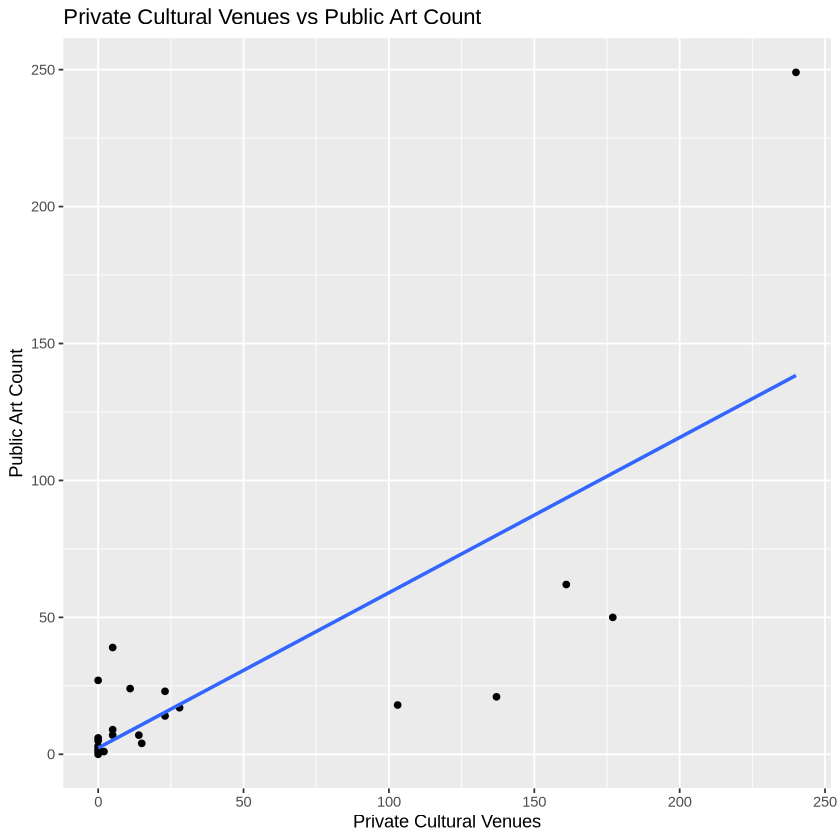

In [46]:
# Number of Private vs. Public art count => Private goes up, Public art goes up
ggplot(final_data, aes(x = Private, y = Public_Art_Count)) +
    geom_point() +
    geom_smooth(method = "lm", se = FALSE, formula = y ~ x) +
    ggtitle("Private Cultural Venues vs Public Art Count") +
    xlab("Private Cultural Venues") +
    ylab("Public Art Count")

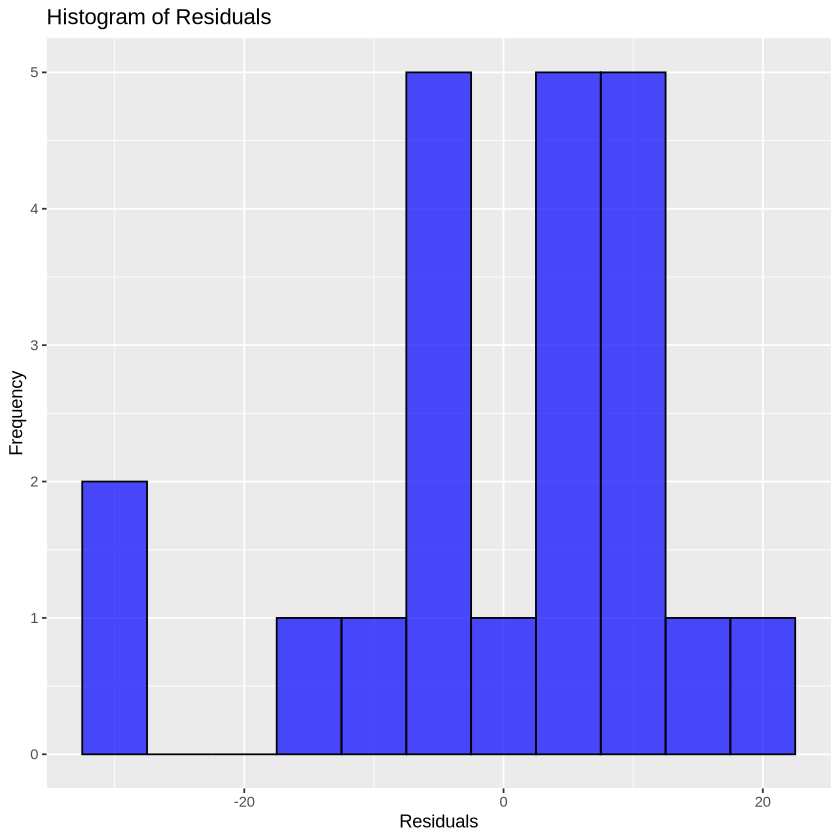

In [47]:
# Really bad residual histogram, should be bell shaped
ggplot(data.frame(residuals), aes(x = residuals)) +
    geom_histogram(binwidth = 5, fill = "blue", color = "black", alpha = 0.7) +
    ggtitle("Histogram of Residuals") +
    xlab("Residuals") +
    ylab("Frequency")

In [48]:
# Sub-sample analysis
high_density <- subset(final_data, PD > median(PD))
low_density <- subset(final_data, PD <= median(PD))
cat("\nHigh-Density Sub-sample Analysis:\n")
summary(lm(Public_Art_Count ~ Private * PD + I(PD^2), data = high_density))
cat("\nLow-Density Sub-sample Analysis:\n")
summary(lm(Public_Art_Count ~ Private * PD + I(PD^2), data = low_density))


High-Density Sub-sample Analysis:



Call:
lm(formula = Public_Art_Count ~ Private * PD + I(PD^2), data = high_density)

Residuals:
    Min      1Q  Median      3Q     Max 
-20.923  -3.885  -1.972   4.277  21.448 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept) -1.137e+02  2.085e+02  -0.545   0.6054  
Private     -6.831e-01  3.841e-01  -1.778   0.1256  
PD           5.725e-03  1.072e-02   0.534   0.6125  
I(PD^2)     -6.383e-08  1.334e-07  -0.478   0.6493  
Private:PD   2.797e-05  9.940e-06   2.814   0.0306 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 16.01 on 6 degrees of freedom
Multiple R-squared:  0.9699,	Adjusted R-squared:  0.9499 
F-statistic: 48.38 on 4 and 6 DF,  p-value: 0.0001063



Low-Density Sub-sample Analysis:



Call:
lm(formula = Public_Art_Count ~ Private * PD + I(PD^2), data = low_density)

Residuals:
     Min       1Q   Median       3Q      Max 
-10.0954  -1.6681  -0.1921   1.2799  11.7776 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)  
(Intercept)  6.658e+01  2.369e+01   2.810   0.0308 *
Private      6.402e-01  1.882e-01   3.403   0.0144 *
PD          -8.244e-03  3.319e-03  -2.484   0.0476 *
I(PD^2)      2.552e-07  1.070e-07   2.385   0.0544 .
Private:PD  -2.999e-05  1.323e-05  -2.266   0.0640 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.028 on 6 degrees of freedom
Multiple R-squared:  0.8676,	Adjusted R-squared:  0.7793 
F-statistic: 9.826 on 4 and 6 DF,  p-value: 0.008369


In [49]:
# Leaving out one neighborhood at a time to see how it effects the model
bootstrap_loo <- boot(data = final_data, statistic = function(data, i) {
    lm(Public_Art_Count ~ Private * PD + I(PD^2), data = data[i, ])$coefficients
}, R = nrow(final_data))
cat("\nLeave-One-Out Bootstrap:\n")
print(bootstrap_loo)


Leave-One-Out Bootstrap:

ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = final_data, statistic = function(data, i) {
    lm(Public_Art_Count ~ Private * PD + I(PD^2), data = data[i, 
        ])$coefficients
}, R = nrow(final_data))


Bootstrap Statistics :
         original        bias     std. error
t1*  4.111208e+01 -9.447591e+00 1.934748e+01
t2* -2.149980e-02 -9.332408e-03 3.347111e-01
t3* -3.185176e-03  8.330994e-04 1.728978e-03
t4*  5.617559e-08 -1.289579e-08 3.167071e-08
t5*  1.245364e-05 -1.810642e-06 1.092948e-05


In [50]:
# Bootstrap SE
boot_model <- function(data, indices) {
    d <- data[indices, ]
    coef(lm(Public_Art_Count ~ Private * PD + I(PD^2), data = d))
}
boot_results <- boot(data = final_data, statistic = boot_model, R = 1000)
cat("\nBootstrap Standard Errors:\n")
print(boot_results)


Bootstrap Standard Errors:

ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = final_data, statistic = boot_model, R = 1000)


Bootstrap Statistics :
         original        bias     std. error
t1*  4.111208e+01 -1.211472e+01 1.674019e+01
t2* -2.149980e-02  5.481726e-02 4.641906e-01
t3* -3.185176e-03  1.037055e-03 1.460900e-03
t4*  5.617559e-08 -1.557632e-08 2.629394e-08
t5*  1.245364e-05 -4.376045e-06 1.513881e-05


In [51]:
cat("\nDurbin-Watson Test:\n") # Look to check if DW ~ 2, its checking for autocorrelation
dwtest(private_pd_model)


Durbin-Watson Test:



	Durbin-Watson test

data:  private_pd_model
DW = 1.9601, p-value = 0.4609
alternative hypothesis: true autocorrelation is greater than 0


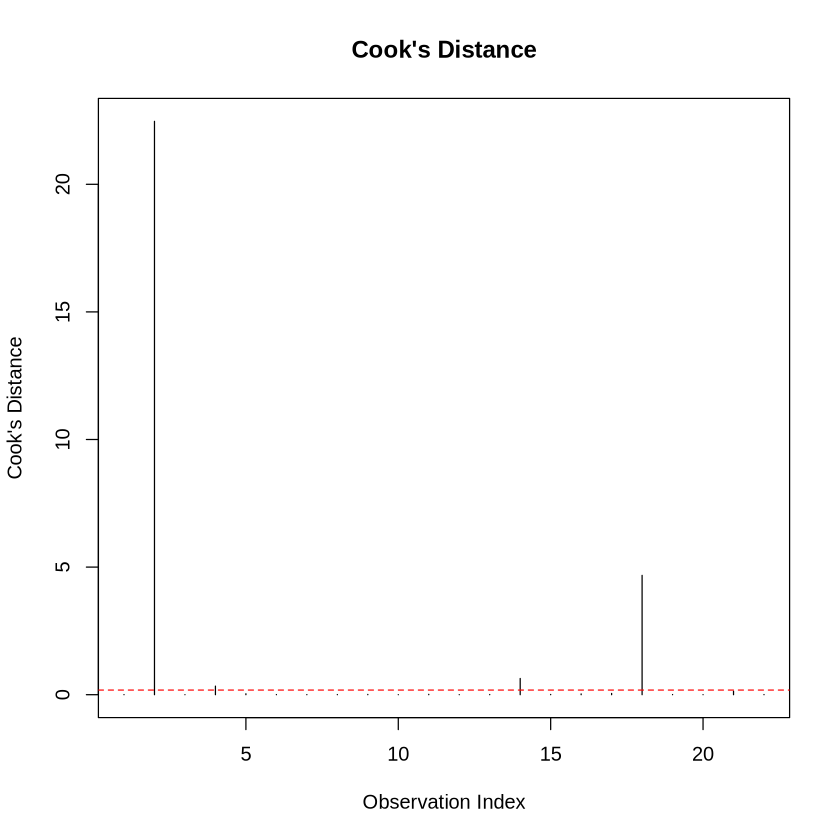

In [52]:
# How does the outcome change if we take out one neighborhood?
cooksD <- cooks.distance(private_pd_model)
plot(cooksD, type = "h", main = "Cook's Distance", xlab = "Observation Index", ylab = "Cook's Distance")
abline(h = 4 / nrow(final_data), col = "red", lty = 2)

In [53]:
# This time its neighborhood 2 and 18 that is significantly influencing the model's output
final_data[c(2, 18), ]

,Neighborhood,AI,PD,Private,Public_Art_Count
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
2,downtown,63251,62030,240,249
18,strathcona,31534,12585,177,50


In [54]:
# Model without neighborhood 2 and 18
model_exclude_DS<- lm(Public_Art_Count ~ Private * PD + I(PD^2), data = final_data[-c(2, 18), ])
summary(model_exclude_DS)


Call:
lm(formula = Public_Art_Count ~ Private * PD + I(PD^2), data = final_data[-c(2, 
    18), ])

Residuals:
    Min      1Q  Median      3Q     Max 
-19.154  -5.230  -1.426   5.029  20.506 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)
(Intercept)  1.912e+01  1.272e+01   1.503    0.154
Private      2.765e-01  7.258e-01   0.381    0.709
PD          -1.303e-03  1.052e-03  -1.239    0.234
I(PD^2)      2.686e-08  1.839e-08   1.460    0.165
Private:PD  -1.371e-06  2.221e-05  -0.062    0.952

Residual standard error: 11.74 on 15 degrees of freedom
Multiple R-squared:  0.5425,	Adjusted R-squared:  0.4205 
F-statistic: 4.447 on 4 and 15 DF,  p-value: 0.01439


In [55]:
# check for covariate names and variables
summary(simple_model)
summary(revised_model)
summary(private_pd_model)

names(coef(simple_model))
names(coef(revised_model))
names(coef(private_pd_model))


Call:
lm(formula = Public_Art_Count ~ Private, data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-58.975  -3.058  -0.758   3.801 110.645 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)   2.3230     8.6029    0.27     0.79    
Private       0.5668     0.1054    5.38 2.89e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 34.26 on 20 degrees of freedom
Multiple R-squared:  0.5914,	Adjusted R-squared:  0.5709 
F-statistic: 28.94 on 1 and 20 DF,  p-value: 2.888e-05



Call:
lm(formula = Public_Art_Count ~ Private + AI + PD, data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-65.011  -9.647   2.340   8.811  67.123 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept) -8.301e+01  2.559e+01  -3.244  0.00451 ** 
Private      4.924e-01  8.824e-02   5.580  2.7e-05 ***
AI           8.061e-04  3.106e-04   2.595  0.01829 *  
PD           1.543e-03  4.513e-04   3.420  0.00305 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 27.33 on 18 degrees of freedom
Multiple R-squared:  0.766,	Adjusted R-squared:  0.727 
F-statistic: 19.64 on 3 and 18 DF,  p-value: 6.591e-06



Call:
lm(formula = Public_Art_Count ~ Private * PD + I(PD^2), data = final_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-30.937  -6.449   3.208   8.925  20.247 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  4.111e+01  1.300e+01   3.164 0.005675 ** 
Private     -2.150e-02  1.069e-01  -0.201 0.842958    
PD          -3.185e-03  9.815e-04  -3.245 0.004761 ** 
I(PD^2)      5.618e-08  1.663e-08   3.378 0.003577 ** 
Private:PD   1.245e-05  2.793e-06   4.459 0.000345 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 14.32 on 17 degrees of freedom
Multiple R-squared:  0.9393,	Adjusted R-squared:  0.9251 
F-statistic: 65.81 on 4 and 17 DF,  p-value: 4.057e-10


[1] "(Intercept)" "Private"

[1] "(Intercept)" "Private"     "AI"          "PD"

[1] "(Intercept)" "Private"     "PD"          "I(PD^2)"     "Private:PD"

In [56]:
# Table of results
stargazer(simple_model,revised_model,private_pd_model, type = "text",
          dep.var.labels = c("Public Art Installations")
          )


                                            Dependent variable:                         
                    --------------------------------------------------------------------
                                          Public Art Installations                      
                             (1)                    (2)                    (3)          
----------------------------------------------------------------------------------------
Private                    0.567***               0.492***                -0.021        
                           (0.105)                (0.088)                (0.107)        
                                                                                        
AI                                                0.001**                               
                                                  (0.0003)                              
                                                                                        
PD                  